# DENTEX Standalone Experiment Runner (Kaggle Dataset + Official-Style Metrics)

This notebook trains and compares controlled variants of:
- **Model A**: pathology detector (box + diagnosis)
- **Model B**: tooth detector (box + enumeration)

It then assigns quadrant and enumeration labels to pathology predictions, exports challenge-style predictions, and reports the official 12 metrics (`AP`, `AP50`, `AP75`, `AR` for Quadrant, Enumeration, Diagnosis) plus aggregate means. Additional analyses include threshold curves, assignment ablations, per-class AP50, error decomposition, oracle benchmarks, and bootstrap confidence intervals.


## 1. Environment Setup

In [1]:
!pip install -q ultralytics==8.3.32 pandas==2.2.2 pycocotools==2.0.8 scipy==1.14.1 matplotlib==3.9.2


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.0/887.0 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 443.5/443.5 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 119.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


In [2]:
import contextlib
import io
import json
import math
import os
import random
import shutil
import time
from collections import defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from scipy.optimize import linear_sum_assignment
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

IS_KAGGLE = Path('/kaggle').exists()
BASE_WORK_ROOT = Path('/kaggle/working') if IS_KAGGLE else Path('.')
PROJECT_DIRNAME = 'dentex_baseline_standalone'

CFG = {
    'is_kaggle': IS_KAGGLE,
    'kaggle_dataset_url': 'https://www.kaggle.com/datasets/lemhui/dentex',
    'kaggle_dataset_root': Path('/kaggle/input/datasets/lemhui/dentex'),
    'work_root': BASE_WORK_ROOT / PROJECT_DIRNAME,
    'yolo_root': BASE_WORK_ROOT / PROJECT_DIRNAME / 'yolo',
    'runs_root': BASE_WORK_ROOT / PROJECT_DIRNAME / 'runs',
    'pred_root': BASE_WORK_ROOT / PROJECT_DIRNAME / 'predictions',
    'official_eval_root': BASE_WORK_ROOT / PROJECT_DIRNAME / 'official_eval',
    'pathology_class_names': [],
    'enumeration_class_names': [f'tooth_{i}' for i in range(1, 9)],
    'imgsz': 1024,
    'epochs': 100,
    'sanity_mode': False,
    'sanity_epochs': 1,
    'sanity_fraction': 0.1,
    'sanity_imgsz': 640,
    'sanity_batch': 4,
    'sanity_max_eval_images': 24,
    'sanity_max_test_images': 40,
    'batch': 8,
    'patience': 20,
    'device': 0 if torch.cuda.is_available() else 'cpu',
    'workers': min(8, max(2, (os.cpu_count() or 4) // 2)),
    'cache': False,
    'optimizer': 'AdamW',
    'lr0': 0.01,
    'mosaic': 0.1,
    'mixup': 0.0,
    'degrees': 8.0,
    'translate': 0.03,
    'scale': 0.15,
    'hsv_h': 0.01,
    'hsv_s': 0.15,
    'hsv_v': 0.15,
    'fliplr': 0.0,
    'flipud': 0.0,
    'predict_conf': 0.25,
    'predict_iou': 0.5,
    'pathology_conf_grid': [0.15, 0.25, 0.35],
    'tooth_conf_grid': [0.15, 0.25, 0.35],
    'predict_iou_grid': [0.45, 0.5, 0.55],
    'enable_tta': True,
    'tta_fusion_iou': 0.55,
    'enable_threshold_tuning': True,
    'enable_bootstrap_ci': True,
    'bootstrap_iterations': 200,
    'prune_heavy_outputs': True,
}

EXPERIMENTS = [
    {
        'name': 'baseline_yolo11n_1024',
        'pathology_model': 'yolo11n.pt',
        'tooth_model': 'yolo11n.pt',
        'imgsz': 1024,
        'epochs': 100,
        'mosaic': 0.1,
        'scale': 0.15,
        'degrees': 8.0,
        'enable_tta': False,
        'assignment_mode': 'hungarian',
    },
    {
        'name': 'larger_pathology_yolo11s',
        'pathology_model': 'yolo11s.pt',
        'tooth_model': 'yolo11n.pt',
        'imgsz': 1024,
        'epochs': 100,
        'mosaic': 0.1,
        'scale': 0.15,
        'degrees': 8.0,
        'enable_tta': False,
        'assignment_mode': 'hungarian',
    },
    {
        'name': 'higher_resolution_1280',
        'pathology_model': 'yolo11n.pt',
        'tooth_model': 'yolo11n.pt',
        'imgsz': 1280,
        'epochs': 100,
        'mosaic': 0.1,
        'scale': 0.15,
        'degrees': 8.0,
        'enable_tta': False,
        'assignment_mode': 'hungarian',
    },
    {
        'name': 'low_augmentation',
        'pathology_model': 'yolo11n.pt',
        'tooth_model': 'yolo11n.pt',
        'imgsz': 1024,
        'epochs': 100,
        'mosaic': 0.0,
        'scale': 0.05,
        'degrees': 3.0,
        'enable_tta': False,
        'assignment_mode': 'hungarian',
    },
    {
        'name': 'baseline_with_tta',
        'pathology_model': 'yolo11n.pt',
        'tooth_model': 'yolo11n.pt',
        'imgsz': 1024,
        'epochs': 100,
        'mosaic': 0.1,
        'scale': 0.15,
        'degrees': 8.0,
        'enable_tta': True,
        'assignment_mode': 'hungarian',
    },
]

ASSIGNMENT_ABLATIONS = ['nearest', 'iou_first', 'hungarian']

if CFG['sanity_mode']:
    CFG['epochs'] = CFG['sanity_epochs']
    CFG['patience'] = 1
    CFG['imgsz'] = CFG['sanity_imgsz']
    CFG['batch'] = CFG['sanity_batch']
    CFG['predict_conf'] = 0.05
    CFG['predict_iou'] = 0.4
    CFG['enable_threshold_tuning'] = False
    CFG['enable_tta'] = False
    CFG['bootstrap_iterations'] = 20
    CFG['pathology_conf_grid'] = [CFG['predict_conf']]
    CFG['tooth_conf_grid'] = [CFG['predict_conf']]
    CFG['predict_iou_grid'] = [CFG['predict_iou']]
    EXPERIMENTS = [dict(EXPERIMENTS[0], imgsz=CFG['sanity_imgsz'], epochs=CFG['sanity_epochs'], enable_tta=False)]

for path_key in [
    'work_root',
    'yolo_root',
    'runs_root',
    'pred_root',
    'official_eval_root',
]:
    CFG[path_key].mkdir(parents=True, exist_ok=True)

print(f"Kaggle runtime: {CFG['is_kaggle']}")
print(f"Device: {CFG['device']}")
print(f"Workers: {CFG['workers']}")
print(f"Working root: {CFG['work_root']}")
print(f"Dataset URL: {CFG['kaggle_dataset_url']}")
print(f"Sanity mode: {CFG['sanity_mode']}")
print(f"Experiment count: {len(EXPERIMENTS)}")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Kaggle runtime: True
Device: 0
Workers: 2
Working root: /kaggle/working/dentex_baseline_standalone
Dataset URL: https://www.kaggle.com/datasets/lemhui/dentex
Sanity mode: False
Experiment count: 5


## 2. Resolve Official DENTEX Splits From Kaggle Dataset

In [3]:
def resolve_kaggle_dataset_root() -> Path:
    dataset_root = CFG['kaggle_dataset_root']
    if not dataset_root.exists() or not dataset_root.is_dir():
        raise FileNotFoundError(
            f"Required dataset directory not found: {dataset_root}"
        )

    has_training = (dataset_root / 'training_data').exists()
    has_validation = (dataset_root / 'validation_data').exists()
    has_test = (dataset_root / 'test_data').exists()
    if not (has_training and has_validation and has_test):
        raise FileNotFoundError(
            f"Dataset directory exists but expected split folders are missing under: {dataset_root}"
        )

    return dataset_root


def json_candidates(root: Path) -> List[Path]:
    if not root.exists():
        return []
    return sorted(
        [path for path in root.rglob('*') if path.is_file() and path.suffix.lower() == '.json']
    )


def find_annotation_json(split_root: Path, split_name: str | None = None) -> Path:
    dataset_root = CFG['kaggle_dataset_root']

    def is_coco_json(path: Path) -> bool:
        try:
            with path.open('r', encoding='utf-8') as file:
                payload = json.load(file)
        except Exception:
            return False
        return isinstance(payload, dict) and {'images', 'annotations'}.issubset(payload.keys())

    split_jsons = json_candidates(split_root)
    split_coco = [path for path in split_jsons if is_coco_json(path)]

    if split_name == 'validation':
        validation_triple = dataset_root / 'validation_triple.json'
        if validation_triple.exists() and is_coco_json(validation_triple):
            return validation_triple
        raise FileNotFoundError(
            f'Validation COCO JSON not found at expected path: {validation_triple}'
        )

    if split_name == 'training':
        if split_coco:
            ranked = sorted(
                split_coco,
                key=lambda path: (
                    'quadrant-enumeration-disease' not in str(path).lower().replace('_', '-'),
                    len(str(path)),
                ),
            )
            return ranked[0]
        raise FileNotFoundError(
            f'No COCO-style training annotation JSON found inside split root: {split_root}'
        )

    if split_name == 'test':
        raise FileNotFoundError(
            'This Kaggle layout stores test labels as per-image LabelMe JSON files, not a single COCO annotation JSON.'
        )

    if split_name is None and split_coco:
        return split_coco[0]

    dataset_jsons = json_candidates(dataset_root) if dataset_root.exists() else []
    dataset_coco = [path for path in dataset_jsons if is_coco_json(path)]
    if dataset_coco:
        return dataset_coco[0]

    raise FileNotFoundError(
        f'No COCO-style annotation JSON found for split={split_name} under {split_root}'
    )


def find_image_root(annotation_path: Path, first_image_file: str, split_root: Path | None = None) -> Path:
    candidates = [
        annotation_path.parent / 'xrays',
        annotation_path.parent,
        annotation_path.parents[1] / 'xrays',
        annotation_path.parents[1],
    ]

    if split_root is not None:
        candidates.extend([
            split_root / 'xrays',
            split_root,
            split_root / 'training_data',
            split_root / 'validation_data',
        ])

    dataset_root = CFG['kaggle_dataset_root']
    candidates.extend([
        dataset_root / 'training_data',
        dataset_root / 'validation_data',
        dataset_root,
    ])

    first_rel = Path(first_image_file)
    first_name = first_rel.name

    dedup = []
    seen = set()
    for root in candidates:
        key = str(root)
        if key in seen:
            continue
        seen.add(key)
        dedup.append(root)

    for root in dedup:
        if (root / first_rel).exists():
            return root
        if (root / first_name).exists():
            return root

    for root in dedup:
        if not root.exists() or not root.is_dir():
            continue
        matches = list(root.rglob(first_name))
        if matches:
            return matches[0].parent

    raise FileNotFoundError(
        f'Image root not found for {annotation_path} with first file {first_image_file}'
    )


def resolve_split_roots(dataset_root: Path) -> Dict[str, Path]:
    split_roots = {
        'training': dataset_root / 'training_data',
        'validation': dataset_root / 'validation_data',
        'test': dataset_root / 'test_data',
    }

    for split_name, split_root in split_roots.items():
        if not split_root.exists():
            raise FileNotFoundError(f'Missing split directory for {split_name}: {split_root}')

    return split_roots


dataset_root = resolve_kaggle_dataset_root()
split_roots = resolve_split_roots(dataset_root)
print(f'Kaggle dataset root: {dataset_root}')
print('Splits:', {k: str(v) for k, v in split_roots.items()})


Kaggle dataset root: /kaggle/input/datasets/lemhui/dentex
Splits: {'training': '/kaggle/input/datasets/lemhui/dentex/training_data', 'validation': '/kaggle/input/datasets/lemhui/dentex/validation_data', 'test': '/kaggle/input/datasets/lemhui/dentex/test_data'}


## 3. Leakage Guardrails And Split Integrity

In [4]:
VALID_IMAGE_SUFFIXES = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}


def list_split_images(split_name: str, split_root: Path) -> List[Path]:
    if split_name == 'test':
        test_input = split_root / 'disease' / 'input'
        roots = [test_input, split_root]
    else:
        roots = [split_root]

    images: List[Path] = []
    for root in roots:
        if not root.exists():
            continue
        for path in root.rglob('*'):
            if path.is_file() and path.suffix.lower() in VALID_IMAGE_SUFFIXES:
                images.append(path)

    # De-duplicate by resolved path.
    unique = []
    seen = set()
    for path in sorted(images):
        key = str(path.resolve())
        if key not in seen:
            seen.add(key)
            unique.append(path)
    return unique


def load_split_index(split_name: str, split_root: Path) -> pd.DataFrame:
    if split_name in {'training', 'validation'}:
        annotation_path = find_annotation_json(split_root, split_name=split_name)
        print(f"{split_name} annotation: {annotation_path}")
        with annotation_path.open('r', encoding='utf-8') as file:
            payload = json.load(file)

        rows = [
            {
                'split': split_name,
                'image_id': int(image['id']),
                'file_name': str(Path(image['file_name']).name),
                'width': int(image.get('width', -1)),
                'height': int(image.get('height', -1)),
            }
            for image in payload['images']
        ]
        return pd.DataFrame(rows)

    # test split in this Kaggle dataset is not COCO aggregate JSON.
    image_files = list_split_images(split_name, split_root)
    print(f"{split_name} annotation: <labelme-per-image-json>")
    print(f"{split_name} image file count from tree: {len(image_files)}")
    rows = [
        {
            'split': split_name,
            'image_id': idx,
            'file_name': path.name,
            'width': -1,
            'height': -1,
        }
        for idx, path in enumerate(image_files)
    ]
    return pd.DataFrame(rows)


split_indices = []
for name in ['training', 'validation', 'test']:
    split_indices.append(load_split_index(name, split_roots[name]))

split_index = pd.concat(split_indices, ignore_index=True)
display(split_index.groupby('split').size().rename('images').to_frame())
print('Unique filenames by split:')
for name in ['training', 'validation', 'test']:
    n_unique = split_index[split_index['split'] == name]['file_name'].nunique()
    print(f'  {name}: {n_unique}')

training_names = set(split_index[split_index['split'] == 'training']['file_name'])
validation_names = set(split_index[split_index['split'] == 'validation']['file_name'])
test_names = set(split_index[split_index['split'] == 'test']['file_name'])

assert training_names.isdisjoint(validation_names), 'Leakage: training/validation overlap'
assert training_names.isdisjoint(test_names), 'Leakage: training/test overlap'
assert validation_names.isdisjoint(test_names), 'Leakage: validation/test overlap'

print('No filename overlap detected across training, validation, and test splits')


training annotation: /kaggle/input/datasets/lemhui/dentex/training_data/training_data/quadrant-enumeration-disease/train_quadrant_enumeration_disease.json
validation annotation: /kaggle/input/datasets/lemhui/dentex/validation_triple.json
test annotation: <labelme-per-image-json>
test image file count from tree: 250


,images
split,
test,250
training,705
validation,50


Unique filenames by split:
  training: 705
  validation: 50
  test: 250
No filename overlap detected across training, validation, and test splits


## 4. Convert Official Splits To YOLO Datasets

In [5]:
def normalise_label(name: str) -> str:
    return ' '.join(str(name).strip().lower().replace('-', ' ').replace('_', ' ').split())


def label_to_yaml_name(label: str) -> str:
    return normalise_label(label).replace(' ', '_')


def clip_bbox_xywh(
    x: float,
    y: float,
    w: float,
    h: float,
    width: int,
    height: int,
) -> Tuple[float, float, float, float]:
    x1 = max(0.0, x)
    y1 = max(0.0, y)
    x2 = min(float(width), x + max(0.0, w))
    y2 = min(float(height), y + max(0.0, h))
    return x1, y1, max(0.0, x2 - x1), max(0.0, y2 - y1)


def xywh_to_yolo(
    x: float,
    y: float,
    w: float,
    h: float,
    width: int,
    height: int,
) -> Tuple[float, float, float, float]:
    xc = (x + 0.5 * w) / float(width)
    yc = (y + 0.5 * h) / float(height)
    return xc, yc, w / float(width), h / float(height)


def ensure_clean_dir(path: Path) -> None:
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)


def build_pathology_schema(training_split_root: Path) -> Tuple[Dict[int, int], Dict[int, int], List[str], pd.DataFrame]:
    annotation_path = find_annotation_json(training_split_root, split_name='training')
    with annotation_path.open('r', encoding='utf-8') as file:
        payload = json.load(file)

    categories = sorted(payload['categories_3'], key=lambda item: int(item['id']))
    cat3_id_to_cls = {}
    cls_to_cat3_id = {}
    class_names = []
    rows = []

    for cls_idx, category in enumerate(categories):
        cat3_id = int(category['id'])
        cat3_name = normalise_label(category['name'])
        cat3_id_to_cls[cat3_id] = cls_idx
        cls_to_cat3_id[cls_idx] = cat3_id
        class_names.append(label_to_yaml_name(cat3_name))
        rows.append(
            {
                'cat3_id': cat3_id,
                'cat3_name': cat3_name,
                'model_cls': cls_idx,
                'yaml_name': label_to_yaml_name(cat3_name),
            }
        )

    schema_df = pd.DataFrame(rows)
    return cat3_id_to_cls, cls_to_cat3_id, class_names, schema_df


def convert_split_to_yolo(
    source_split: str,
    output_split: str,
    task_name: str,
    output_root: Path,
    pathology_cat3_to_cls: Dict[int, int],
) -> Dict[str, object]:
    if source_split not in {'training', 'validation'}:
        raise ValueError(f'COCO conversion is only supported for training/validation, got: {source_split}')

    split_root = split_roots[source_split]
    annotation_path = find_annotation_json(split_root, split_name=source_split)

    with annotation_path.open('r', encoding='utf-8') as file:
        payload = json.load(file)

    images = payload['images']
    annotations = payload['annotations']

    by_image = defaultdict(list)
    for annotation in annotations:
        by_image[int(annotation['image_id'])].append(annotation)

    image_root = find_image_root(annotation_path, images[0]['file_name'], split_root=split_root)

    image_dir = output_root / 'images' / output_split
    label_dir = output_root / 'labels' / output_split
    image_dir.mkdir(parents=True, exist_ok=True)
    label_dir.mkdir(parents=True, exist_ok=True)

    kept_images = 0
    kept_boxes = 0
    missing_images = 0

    for image in images:
        image_id = int(image['id'])
        width = int(image['width'])
        height = int(image['height'])
        image_path = image_root / image['file_name']
        if not image_path.exists():
            missing_images += 1
            continue

        lines = []
        for annotation in by_image.get(image_id, []):
            x, y, w, h = [float(v) for v in annotation['bbox']]
            x, y, w, h = clip_bbox_xywh(x, y, w, h, width, height)
            if w <= 1.0 or h <= 1.0:
                continue

            if task_name == 'pathology':
                cat3_id = int(annotation['category_id_3'])
                if cat3_id not in pathology_cat3_to_cls:
                    continue
                cls_id = pathology_cat3_to_cls[cat3_id]
            elif task_name == 'tooth_enumeration':
                cls_id = int(annotation['category_id_2'])
                if not (0 <= cls_id < 8):
                    continue
            else:
                raise ValueError(f'Unsupported task: {task_name}')

            xc, yc, wn, hn = xywh_to_yolo(x, y, w, h, width, height)
            lines.append(f'{cls_id} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}')

        dst_image = image_dir / Path(image['file_name']).name
        dst_label = label_dir / f"{Path(image['file_name']).stem}.txt"
        shutil.copy2(image_path, dst_image)
        if lines:
            dst_label.write_text('\n'.join(lines) + '\n', encoding='utf-8')
        else:
            dst_label.write_text('', encoding='utf-8')

        kept_images += 1
        kept_boxes += len(lines)

    split_txt = output_root / f'{output_split}.txt'
    image_paths = sorted(str(path.resolve()) for path in image_dir.glob('*'))
    split_txt.write_text('\n'.join(image_paths) + '\n', encoding='utf-8')

    if missing_images:
        print(f'Skipped missing images in {source_split}: {missing_images}')

    return {
        'task': task_name,
        'source_split': source_split,
        'output_split': output_split,
        'images': kept_images,
        'boxes': kept_boxes,
        'annotation_path': str(annotation_path),
    }


def write_dataset_yaml(dataset_root: Path, class_names: List[str]) -> Path:
    yaml_lines = [
        f'path: {dataset_root.resolve()}',
        'train: train.txt',
        'val: validation.txt',
        'test: test.txt',
        'names:',
    ]
    yaml_lines += [f'  {idx}: {name}' for idx, name in enumerate(class_names)]
    yaml_path = dataset_root / 'dataset.yaml'
    yaml_path.write_text('\n'.join(yaml_lines) + '\n', encoding='utf-8')
    return yaml_path


def write_test_lists_for_tasks(task_roots: List[Path]) -> None:
    test_images = list_split_images('test', split_roots['test'])
    test_paths = [str(path.resolve()) for path in test_images]

    for task_root in task_roots:
        (task_root / 'images' / 'test').mkdir(parents=True, exist_ok=True)
        (task_root / 'labels' / 'test').mkdir(parents=True, exist_ok=True)
        (task_root / 'test.txt').write_text('\n'.join(test_paths) + '\n', encoding='utf-8')

    print(f'Wrote test image lists with {len(test_paths)} images')


PATHOLOGY_CAT3_TO_CLS, PATHOLOGY_CLS_TO_CAT3, pathology_class_names, pathology_schema_df = build_pathology_schema(
    split_roots['training']
)
CFG['pathology_class_names'] = pathology_class_names

print('Pathology class mapping:')
display(pathology_schema_df)

pathology_root = CFG['yolo_root'] / 'pathology'
tooth_root = CFG['yolo_root'] / 'tooth_enumeration'
ensure_clean_dir(pathology_root)
ensure_clean_dir(tooth_root)

conversion_rows = []
split_mapping = {
    'train': 'training',
    'validation': 'validation',
}

for output_split, source_split in split_mapping.items():
    conversion_rows.append(
        convert_split_to_yolo(
            source_split=source_split,
            output_split=output_split,
            task_name='pathology',
            output_root=pathology_root,
            pathology_cat3_to_cls=PATHOLOGY_CAT3_TO_CLS,
        )
    )
    conversion_rows.append(
        convert_split_to_yolo(
            source_split=source_split,
            output_split=output_split,
            task_name='tooth_enumeration',
            output_root=tooth_root,
            pathology_cat3_to_cls=PATHOLOGY_CAT3_TO_CLS,
        )
    )

write_test_lists_for_tasks([pathology_root, tooth_root])

pathology_yaml = write_dataset_yaml(pathology_root, CFG['pathology_class_names'])
tooth_yaml = write_dataset_yaml(tooth_root, CFG['enumeration_class_names'])

conversion_df = pd.DataFrame(conversion_rows)
display(conversion_df)
print(f'Pathology data YAML: {pathology_yaml}')
print(f'Tooth enumeration data YAML: {tooth_yaml}')


Pathology class mapping:


,cat3_id,cat3_name,model_cls,yaml_name
0,0,impacted,0,impacted
1,1,caries,1,caries
2,2,periapical lesion,2,periapical_lesion
3,3,deep caries,3,deep_caries


Wrote test image lists with 250 images


,task,source_split,output_split,images,boxes,annotation_path
0,pathology,training,train,705,3529,/kaggle/input/datasets/lemhui/dentex/training_...
1,tooth_enumeration,training,train,705,3529,/kaggle/input/datasets/lemhui/dentex/training_...
2,pathology,validation,validation,50,182,/kaggle/input/datasets/lemhui/dentex/validatio...
3,tooth_enumeration,validation,validation,50,182,/kaggle/input/datasets/lemhui/dentex/validatio...


Pathology data YAML: /kaggle/working/dentex_baseline_standalone/yolo/pathology/dataset.yaml
Tooth enumeration data YAML: /kaggle/working/dentex_baseline_standalone/yolo/tooth_enumeration/dataset.yaml


## 5. YOLO Training Helper


In [6]:
def patch_ray_session_api() -> None:
    try:
        import ray.train._internal.session as ray_session
    except Exception as err:
        print(f'Ray patch skipped: {err}')
        return

    if not hasattr(ray_session, '_get_session'):
        def _get_session():
            return None

        ray_session._get_session = _get_session
        print('Applied Ray callback compatibility patch.')


def patch_ultralytics_ray_callback() -> None:
    try:
        from ultralytics.utils.callbacks import raytune as raytune_cb
    except Exception:
        return

    def _noop_on_fit_epoch_end(trainer):
        return None

    raytune_cb.on_fit_epoch_end = _noop_on_fit_epoch_end

    try:
        from ultralytics.utils.callbacks import base as callback_base

        for event, callbacks in callback_base.default_callbacks.items():
            callback_base.default_callbacks[event] = [
                cb for cb in callbacks if getattr(cb, '__module__', '') != raytune_cb.__name__
            ]
    except Exception:
        pass


def disable_ray_tune_callbacks(model: YOLO) -> None:
    removed = 0
    for event, callbacks in model.callbacks.items():
        kept = [cb for cb in callbacks if 'raytune' not in cb.__module__]
        removed += len(callbacks) - len(kept)
        model.callbacks[event] = kept
    if removed:
        print(f'Removed {removed} Ray Tune callback(s) from Ultralytics model')


class LineEpochIterator:
    def __init__(self, iterable=None, *args, **kwargs):
        self.iterable = iterable if iterable is not None else []
        self.description = None

    def __iter__(self):
        for item in self.iterable:
            yield item
        if self.description:
            print(str(self.description).strip())

    def set_description(self, description=None, refresh=True):
        self.description = description

    def update(self, n=1):
        return None

    def close(self):
        return None

    def __enter__(self):
        return self

    def __exit__(self, exc_type, exc_value, traceback):
        self.close()


class UltralyticsEpochHeaderFilter:
    def filter(self, record):
        message = record.getMessage().strip()
        return not message.startswith('Epoch')


def patch_ultralytics_epoch_output() -> None:
    from ultralytics import utils as ultralytics_utils
    from ultralytics.engine import trainer as ultralytics_trainer

    setattr(ultralytics_utils, 'T' + 'QDM', LineEpochIterator)
    setattr(ultralytics_trainer, 'T' + 'QDM', LineEpochIterator)

    try:
        from ultralytics.engine import validator as ultralytics_validator

        setattr(ultralytics_validator, 'T' + 'QDM', LineEpochIterator)
    except Exception:
        pass

    logger = ultralytics_utils.LOGGER
    if not any(isinstance(item, UltralyticsEpochHeaderFilter) for item in logger.filters):
        logger.addFilter(UltralyticsEpochHeaderFilter())


def experiment_value(exp_cfg: dict, key: str):
    if CFG['sanity_mode'] and key in {'epochs', 'imgsz'}:
        return CFG[key]
    return exp_cfg.get(key, CFG[key])


def train_yolo_baseline(
    model_source: str,
    run_name: str,
    data_yaml: Path,
    exp_cfg: dict,
) -> Tuple[object, Path]:
    patch_ray_session_api()
    patch_ultralytics_ray_callback()
    patch_ultralytics_epoch_output()

    model = YOLO(model_source)
    disable_ray_tune_callbacks(model)

    start = time.time()
    result = model.train(
        data=str(data_yaml),
        epochs=experiment_value(exp_cfg, 'epochs'),
        imgsz=experiment_value(exp_cfg, 'imgsz'),
        batch=CFG['batch'],
        project=str(CFG['runs_root']),
        name=run_name,
        exist_ok=True,
        device=CFG['device'],
        workers=CFG['workers'],
        cache=CFG['cache'],
        optimizer=CFG['optimizer'],
        lr0=CFG['lr0'],
        patience=CFG['patience'],
        seed=SEED,
        deterministic=True,
        mosaic=exp_cfg.get('mosaic', CFG['mosaic']),
        mixup=CFG['mixup'],
        degrees=exp_cfg.get('degrees', CFG['degrees']),
        translate=CFG['translate'],
        scale=exp_cfg.get('scale', CFG['scale']),
        hsv_h=CFG['hsv_h'],
        hsv_s=CFG['hsv_s'],
        hsv_v=CFG['hsv_v'],
        fliplr=CFG['fliplr'],
        flipud=CFG['flipud'],
        plots=False,
        fraction=CFG['sanity_fraction'] if CFG['sanity_mode'] else 1.0,
    )
    elapsed = round(time.time() - start, 2)

    run_dir = CFG['runs_root'] / run_name
    best_weights = run_dir / 'weights' / 'best.pt'
    print(f'Run: {run_name}')
    print(f'Elapsed seconds: {elapsed}')
    print(f'Best weights: {best_weights}')
    return result, best_weights


## 6. Experiment Runner, Prediction Analysis, And Validation Outputs


Quadrant orientation map: {'upper_left': 0, 'upper_right': 1, 'lower_left': 3, 'lower_right': 2}
Diagnosis id map: {0: 0, 1: 1, 2: 2, 3: 3}
Running experiment: baseline_yolo11n_1024
Applied Ray callback compatibility patch.


100%|██████████| 5.35M/5.35M [00:00<00:00, 78.5MB/s]


New https://pypi.org/project/ultralytics/8.4.41 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.32 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/kaggle/working/dentex_baseline_standalone/yolo/pathology/dataset.yaml, epochs=100, time=None, patience=20, batch=8, imgsz=1024, save=True, save_period=-1, cache=False, device=0, workers=2, project=/kaggle/working/dentex_baseline_standalone/runs, name=baseline_yolo11n_1024_pathology, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize

100%|██████████| 755k/755k [00:00<00:00, 18.3MB/s]
E0000 00:00:1777087467.954839      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777087468.013612      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777087468.479073      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777087468.479107      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777087468.479110      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777087468.479112      23 computation_placer.cc:177] comput

Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics

...

/usr/local/lib/python3.12/dist-packages/ultralytics/data/augment.py:1850: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),


91/100      3.06G     0.8644     0.5981     0.9833         11       1024
                   all         50        182      0.305      0.458      0.338      0.196
92/100      3.05G      0.847     0.5716     0.9789          9       1024
                   all         50        182      0.301      0.457      0.346      0.194
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 72, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

92 epochs completed in 1.045 hours.
Optimizer stripped from /kaggle/working/dentex_baseline_standalone/runs/baseline_with_tta_tooth/weights/last.pt, 5.5MB
Optimizer stripped from /kaggle/working/dentex_baseline_standalone/runs/baseline_with_tta_tooth/weights/best.pt, 5.5MB

Validating /kaggle/working/dentex_baseline_standalone/runs/baseline_with_tta_tooth/weights/best.pt...
Ultralytics 8.3.32 🚀

,experiment,pathology_model,tooth_model,imgsz,mosaic,scale,degrees,tta,assignment_mode,n_predictions,quadrant_AP50,enumeration_AP50,diagnosis_AP50,aggregate_AP50,quadrant_AP,enumeration_AP,diagnosis_AP,aggregate_AP,aggregate_AP75,aggregate_AR
0,baseline_with_tta,yolo11n.pt,yolo11n.pt,1024,0.1,0.15,8.0,True,hungarian,364,0.001484,0.327134,0.425054,0.251224,0.000840,0.182804,0.246064,0.143236,0.134487,0.230712
1,baseline_yolo11n_1024,yolo11n.pt,yolo11n.pt,1024,0.1,0.15,8.0,False,hungarian,194,0.001292,0.296676,0.404065,0.234011,0.000744,0.188904,0.250130,0.146592,0.171213,0.209901
2,larger_pathology_yolo11s,yolo11s.pt,yolo11n.pt,1024,0.1,0.15,8.0,False,hungarian,212,0.002171,0.248810,0.421214,0.224065,0.001561,0.156444,0.259751,0.139252,0.157448,0.204252
3,low_augmentation,yolo11n.pt,yolo11n.pt,1024,0.0,0.05,3.0,False,hungarian,185,0.001482,0.292155,0.371240,0.221626,0.000985,0.177959,0.243714,0.140886,0.161002,0.193374
4,higher_resolution_1280,yolo11n.pt,yolo11n.pt,1280,0.1,0.15,8.0,False,hungarian,161,0.003307,0.213896,0.328686,0.181963,0.002595,0.146296,0.211112,0.120001,0.136273,0.171334


Best validation experiment by aggregate AP50: baseline_with_tta
validation_tune_pc0.15_tc0.15_iou0.45 prediction count: 466
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
validation_tune_pc0.15_tc0.15_iou0.5 prediction count: 468
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index create

,pathology_conf,tooth_conf,predict_iou,predictions,aggregate_AP,aggregate_AP50,aggregate_AP75,aggregate_AR
0,0.15,0.25,0.50,408,0.152267,0.259509,0.150966,0.240579
1,0.15,0.25,0.55,408,0.152267,0.259509,0.150966,0.240579
2,0.15,0.25,0.45,406,0.152648,0.255368,0.152516,0.240058
3,0.25,0.15,0.45,405,0.145385,0.254093,0.138507,0.234113
4,0.25,0.15,0.50,405,0.145377,0.254074,0.138502,0.234113
5,0.25,0.15,0.55,406,0.145360,0.254043,0.138480,0.234113
6,0.15,0.15,0.45,466,0.147439,0.253271,0.144102,0.245083
7,0.15,0.15,0.50,468,0.147255,0.252934,0.143897,0.245083
8,0.15,0.15,0.55,468,0.147221,0.252870,0.143874,0.245083
9,0.25,0.25,0.45,362,0.143247,0.251251,0.134496,0.230712


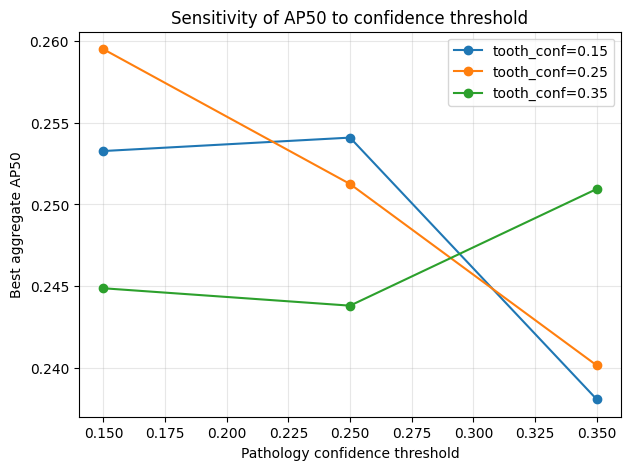

Using pathology conf: 0.15
Using tooth conf: 0.25
Using predict IoU: 0.5
validation_assignment_nearest prediction count: 645
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
validation_assignment_iou_first prediction count: 406
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
l

,experiment,pathology_model,tooth_model,imgsz,mosaic,scale,degrees,tta,assignment_mode,n_predictions,quadrant_AP50,enumeration_AP50,diagnosis_AP50,aggregate_AP50,quadrant_AP,enumeration_AP,diagnosis_AP,aggregate_AP,aggregate_AP75,aggregate_AR
0,assignment_nearest,yolo11n.pt,yolo11n.pt,1024,0.1,0.15,8.0,True,nearest,645,0.001357,0.357106,0.514094,0.290852,0.000776,0.204600,0.303933,0.169770,0.166716,0.290883
1,assignment_iou_first,yolo11n.pt,yolo11n.pt,1024,0.1,0.15,8.0,True,iou_first,406,0.001287,0.334245,0.473193,0.269575,0.000721,0.185952,0.283058,0.156577,0.154702,0.249705
2,assignment_hungarian,yolo11n.pt,yolo11n.pt,1024,0.1,0.15,8.0,True,hungarian,408,0.001499,0.349950,0.427077,0.259509,0.000846,0.202986,0.252968,0.152267,0.150966,0.240579


Best assignment mode by aggregate AP50: nearest


,image_id,bbox,score,quadrant,enumeration,diagnosis
0,50,"[2013.369140625, 752.534423828125, 305.2629394...",0.849081,3,6,2
1,50,"[732.754638671875, 791.02490234375, 316.377929...",0.676074,2,6,1
2,50,"[2012.6708557881584, 757.4936804994171, 300.60...",0.573188,3,6,1
3,50,"[2168.093017578125, 706.135498046875, 263.6467...",0.473945,0,7,1
4,50,"[721.9251708984375, 787.9197998046875, 324.802...",0.407746,2,6,2
5,50,"[1983.2772804675253, 459.61783358048916, 203.7...",0.404000,0,5,1
6,50,"[743.7417602539062, 793.4769897460938, 299.675...",0.386248,2,6,3
7,50,"[693.086174421885, 470.84919241521203, 194.600...",0.376420,1,7,1
8,50,"[1767.81689453125, 830.7889404296875, 138.0758...",0.303191,3,4,1
9,50,"[615.676025390625, 742.0802001953125, 278.7185...",0.279303,2,7,1


Saved validation unified predictions: /kaggle/working/dentex_baseline_standalone/predictions/predictions_unified_validation.json
Saved validation challenge-format predictions: /kaggle/working/dentex_baseline_standalone/predictions/predictions_challenge_format_validation.json
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!


...

validation_gt_tooth_oracle GT-tooth-oracle prediction count: 549
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...

,experiment,quadrant_AP50,enumeration_AP50,diagnosis_AP50,aggregate_AP50,aggregate_AP,aggregate_AP75,aggregate_AR
0,gt_tooth_detector_oracle,0.640024,0.453974,0.538793,0.544264,0.315981,0.310630,0.512518
1,oracle_tooth_labels,0.603674,0.495733,0.514094,0.537834,0.308964,0.299381,0.512518


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
loading annotati

,metric,mean,ci_low,ci_high
0,AP,0.176932,0.136263,0.212345
1,AP50,0.297968,0.241254,0.353002
2,AP75,0.178168,0.124350,0.231398
3,AR,0.289792,0.250952,0.326747


test prediction count: 3225
Saved test unified predictions: /kaggle/working/dentex_baseline_standalone/predictions/predictions_unified_test.json
Saved test challenge-format predictions: /kaggle/working/dentex_baseline_standalone/predictions/predictions_challenge_format_test.json


In [7]:
@dataclass
class DetectedBox:
    cls_id: int
    score: float
    x1: float
    y1: float
    x2: float
    y2: float

    @property
    def cx(self) -> float:
        return 0.5 * (self.x1 + self.x2)

    @property
    def cy(self) -> float:
        return 0.5 * (self.y1 + self.y2)


def yolo_to_boxes(prediction_result) -> List[DetectedBox]:
    if prediction_result.boxes is None:
        return []

    xyxy = prediction_result.boxes.xyxy.cpu().numpy()
    cls_ids = prediction_result.boxes.cls.cpu().numpy().astype(int)
    scores = prediction_result.boxes.conf.cpu().numpy()

    boxes = []
    for coords, cls_id, score in zip(xyxy, cls_ids, scores):
        boxes.append(
            DetectedBox(
                cls_id=int(cls_id),
                score=float(score),
                x1=float(coords[0]),
                y1=float(coords[1]),
                x2=float(coords[2]),
                y2=float(coords[3]),
            )
        )
    return boxes


def iou_xyxy(a: DetectedBox, b: DetectedBox) -> float:
    inter_x1 = max(a.x1, b.x1)
    inter_y1 = max(a.y1, b.y1)
    inter_x2 = min(a.x2, b.x2)
    inter_y2 = min(a.y2, b.y2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter = inter_w * inter_h

    area_a = max(0.0, a.x2 - a.x1) * max(0.0, a.y2 - a.y1)
    area_b = max(0.0, b.x2 - b.x1) * max(0.0, b.y2 - b.y1)
    union = area_a + area_b - inter
    if union <= 0:
        return 0.0
    return inter / union


def bbox_iou_xywh(a, b) -> float:
    ax1, ay1, aw, ah = a
    bx1, by1, bw, bh = b
    ax2, ay2 = ax1 + aw, ay1 + ah
    bx2, by2 = bx1 + bw, by1 + bh

    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)

    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    union = aw * ah + bw * bh - inter
    return inter / union if union > 0 else 0.0


def xyxy_to_xywh(box: DetectedBox) -> List[float]:
    return [box.x1, box.y1, max(0.0, box.x2 - box.x1), max(0.0, box.y2 - box.y1)]


def load_gt_payload(split_name: str) -> dict:
    annotation_path = find_annotation_json(split_roots[split_name], split_name=split_name)
    with annotation_path.open('r', encoding='utf-8') as file:
        return json.load(file)


def diagnosis_name_to_gt_id(gt_payload: dict) -> Dict[str, int]:
    mapping = {}
    for category in gt_payload['categories_3']:
        mapping[normalise_label(category['name'])] = int(category['id'])
    return mapping


def diagnosis_pred_to_gt_id_map(gt_payload: dict) -> Dict[int, int]:
    gt_name_to_id = diagnosis_name_to_gt_id(gt_payload)
    pred_map = {}
    for cls_idx, cat3_id in PATHOLOGY_CLS_TO_CAT3.items():
        row = pathology_schema_df[pathology_schema_df['model_cls'] == cls_idx].iloc[0]
        train_name = normalise_label(row['cat3_name'])
        if train_name in gt_name_to_id:
            pred_map[cls_idx] = int(gt_name_to_id[train_name])
        else:
            pred_map[cls_idx] = int(cat3_id)
    return pred_map


def learn_quadrant_orientation(training_split_root: Path) -> Dict[str, int]:
    annotation_path = find_annotation_json(training_split_root, split_name='training')
    with annotation_path.open('r', encoding='utf-8') as file:
        payload = json.load(file)

    image_by_id = {int(img['id']): img for img in payload['images']}

    rows = []
    for annotation in payload['annotations']:
        img = image_by_id[int(annotation['image_id'])]
        x, y, w, h = annotation['bbox']
        cx_norm = (float(x) + 0.5 * float(w)) / float(img['width'])
        rows.append({'quadrant': int(annotation['category_id_1']), 'cx_norm': cx_norm})

    df = pd.DataFrame(rows)
    upper_ids = [0, 1]
    lower_ids = [2, 3]

    upper_mean = df[df['quadrant'].isin(upper_ids)].groupby('quadrant')['cx_norm'].mean()
    lower_mean = df[df['quadrant'].isin(lower_ids)].groupby('quadrant')['cx_norm'].mean()

    return {
        'upper_left': int(upper_mean.idxmin()),
        'upper_right': int(upper_mean.idxmax()),
        'lower_left': int(lower_mean.idxmin()),
        'lower_right': int(lower_mean.idxmax()),
    }


def get_pca_axes(centres: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    if centres.shape[0] < 2:
        return np.array([-1.0, 0.0], dtype=float), np.array([0.0, 1.0], dtype=float)

    centred = centres - centres.mean(axis=0, keepdims=True)
    _, _, vh = np.linalg.svd(centred, full_matrices=False)

    major_axis = vh[0]
    if vh.shape[0] >= 2:
        minor_axis = vh[1]
    else:
        minor_axis = np.array([0.0, 1.0], dtype=float)

    if major_axis[0] > 0:
        major_axis = -major_axis
    return major_axis, minor_axis


def assign_quadrant_from_layout(
    tooth_boxes: List[DetectedBox],
    orientation_map: Dict[str, int],
) -> Dict[int, int]:
    if not tooth_boxes:
        return {}

    if len(tooth_boxes) == 1:
        return {0: orientation_map['upper_left']}

    centres = np.array([[box.cx, box.cy] for box in tooth_boxes], dtype=float)
    major_axis, minor_axis = get_pca_axes(centres)

    major_scores = centres @ major_axis
    minor_scores = centres @ minor_axis
    major_split = float(np.median(major_scores))
    minor_split = float(np.median(minor_scores))

    mapping = {}
    for idx in range(len(tooth_boxes)):
        is_left = major_scores[idx] <= major_split
        is_upper = minor_scores[idx] <= minor_split
        if is_upper and is_left:
            mapping[idx] = orientation_map['upper_left']
        elif is_upper and not is_left:
            mapping[idx] = orientation_map['upper_right']
        elif not is_upper and is_left:
            mapping[idx] = orientation_map['lower_left']
        else:
            mapping[idx] = orientation_map['lower_right']

    return mapping


def assign_pathology_to_teeth(
    pathology_boxes: List[DetectedBox],
    tooth_boxes: List[DetectedBox],
) -> Dict[int, int]:
    if not pathology_boxes or not tooth_boxes:
        return {}

    cost = np.zeros((len(pathology_boxes), len(tooth_boxes)), dtype=float)

    for i, path_box in enumerate(pathology_boxes):
        for j, tooth_box in enumerate(tooth_boxes):
            overlap = iou_xyxy(path_box, tooth_box)
            dist = math.dist((path_box.cx, path_box.cy), (tooth_box.cx, tooth_box.cy))
            area_path = max(1.0, (path_box.x2 - path_box.x1) * (path_box.y2 - path_box.y1))
            area_tooth = max(1.0, (tooth_box.x2 - tooth_box.x1) * (tooth_box.y2 - tooth_box.y1))
            size_penalty = abs(math.log(area_path / area_tooth))
            cost[i, j] = (
                0.60 * (1.0 - overlap)
                + 0.30 * min(1.0, dist / 400.0)
                + 0.10 * min(1.0, size_penalty / 3.0)
            )

    row_ind, col_ind = linear_sum_assignment(cost)

    assignment = {}
    for row, col in zip(row_ind, col_ind):
        overlap = iou_xyxy(pathology_boxes[row], tooth_boxes[col])
        dist = math.dist(
            (pathology_boxes[row].cx, pathology_boxes[row].cy),
            (tooth_boxes[col].cx, tooth_boxes[col].cy),
        )
        if overlap < 0.01 and dist > 320:
            continue
        assignment[row] = col

    return assignment


def assign_pathology_to_teeth_nearest(
    pathology_boxes: List[DetectedBox],
    tooth_boxes: List[DetectedBox],
) -> Dict[int, int]:
    if not pathology_boxes or not tooth_boxes:
        return {}

    assignment = {}
    for i, path_box in enumerate(pathology_boxes):
        distances = [
            math.dist((path_box.cx, path_box.cy), (tooth_box.cx, tooth_box.cy))
            for tooth_box in tooth_boxes
        ]
        j = int(np.argmin(distances))
        if distances[j] <= 400:
            assignment[i] = j

    return assignment


def assign_pathology_to_teeth_iou_first(
    pathology_boxes: List[DetectedBox],
    tooth_boxes: List[DetectedBox],
) -> Dict[int, int]:
    if not pathology_boxes or not tooth_boxes:
        return {}

    assignment = {}
    used_teeth = set()

    for i, path_box in enumerate(pathology_boxes):
        scores = []
        for j, tooth_box in enumerate(tooth_boxes):
            if j in used_teeth:
                scores.append(-1.0)
            else:
                overlap = iou_xyxy(path_box, tooth_box)
                dist = math.dist((path_box.cx, path_box.cy), (tooth_box.cx, tooth_box.cy))
                scores.append(overlap - 0.001 * dist)

        j = int(np.argmax(scores))
        if scores[j] > -0.3:
            assignment[i] = j
            used_teeth.add(j)

    return assignment


def assign_pathology_to_teeth_by_mode(
    pathology_boxes: List[DetectedBox],
    tooth_boxes: List[DetectedBox],
    assignment_mode: str,
) -> Dict[int, int]:
    if assignment_mode == 'hungarian':
        return assign_pathology_to_teeth(pathology_boxes, tooth_boxes)
    if assignment_mode == 'nearest':
        return assign_pathology_to_teeth_nearest(pathology_boxes, tooth_boxes)
    if assignment_mode == 'iou_first':
        return assign_pathology_to_teeth_iou_first(pathology_boxes, tooth_boxes)
    raise ValueError(f'Unknown assignment_mode: {assignment_mode}')


def fuse_boxes_weighted(
    boxes: List[DetectedBox],
    iou_thr: float,
) -> List[DetectedBox]:
    if not boxes:
        return []

    boxes_sorted = sorted(boxes, key=lambda item: item.score, reverse=True)
    fused = []

    while boxes_sorted:
        anchor = boxes_sorted.pop(0)
        cluster = [anchor]
        remaining = []

        for candidate in boxes_sorted:
            if candidate.cls_id == anchor.cls_id and iou_xyxy(anchor, candidate) >= iou_thr:
                cluster.append(candidate)
            else:
                remaining.append(candidate)
        boxes_sorted = remaining

        weights = np.array([item.score for item in cluster], dtype=float)
        weights = np.maximum(weights, 1e-6)

        x1 = float(np.average([item.x1 for item in cluster], weights=weights))
        y1 = float(np.average([item.y1 for item in cluster], weights=weights))
        x2 = float(np.average([item.x2 for item in cluster], weights=weights))
        y2 = float(np.average([item.y2 for item in cluster], weights=weights))
        score = float(np.max([item.score for item in cluster]))

        fused.append(
            DetectedBox(
                cls_id=anchor.cls_id,
                score=score,
                x1=x1,
                y1=y1,
                x2=x2,
                y2=y2,
            )
        )

    return fused


def predict_boxes_with_tta(
    model: YOLO,
    image_path: str,
    conf: float,
    iou: float,
    enable_tta: bool,
) -> List[DetectedBox]:
    base_result = model.predict(source=image_path, conf=conf, iou=iou, verbose=False)[0]
    base_boxes = yolo_to_boxes(base_result)
    if not enable_tta:
        return base_boxes

    image_np = np.array(Image.open(image_path).convert('RGB'))
    width = int(image_np.shape[1])
    image_flip = np.ascontiguousarray(image_np[:, ::-1, :])

    flip_result = model.predict(source=image_flip, conf=conf, iou=iou, verbose=False)[0]
    flip_boxes = yolo_to_boxes(flip_result)

    flip_boxes_unflipped = []
    for box in flip_boxes:
        flip_boxes_unflipped.append(
            DetectedBox(
                cls_id=box.cls_id,
                score=box.score,
                x1=float(width - box.x2),
                y1=box.y1,
                x2=float(width - box.x1),
                y2=box.y2,
            )
        )

    merged = base_boxes + flip_boxes_unflipped
    return fuse_boxes_weighted(merged, iou_thr=CFG['tta_fusion_iou'])


def parse_test_image_id(file_name: str) -> int:
    stem = Path(file_name).stem
    if stem.startswith('test_'):
        return int(stem.split('_')[-1])
    raise ValueError(f'Cannot parse test image id from filename: {file_name}')


def build_predictions_for_split(
    split_name: str,
    image_paths: List[str],
    image_id_lookup: Dict[str, int],
    pathology_model: YOLO,
    tooth_model: YOLO,
    diagnosis_id_map: Dict[int, int],
    orientation_map: Dict[str, int],
    pathology_conf: float,
    tooth_conf: float,
    predict_iou: float,
    enable_tta: bool,
    assignment_mode: str = 'hungarian',
) -> Tuple[List[dict], List[dict]]:
    unified_predictions = []
    challenge_boxes = []

    for image_path in image_paths:
        file_name = Path(image_path).name
        if file_name not in image_id_lookup:
            continue

        image_id = int(image_id_lookup[file_name])

        pathology_boxes = predict_boxes_with_tta(
            model=pathology_model,
            image_path=image_path,
            conf=pathology_conf,
            iou=predict_iou,
            enable_tta=enable_tta,
        )
        tooth_boxes = predict_boxes_with_tta(
            model=tooth_model,
            image_path=image_path,
            conf=tooth_conf,
            iou=predict_iou,
            enable_tta=enable_tta,
        )

        if not pathology_boxes or not tooth_boxes:
            continue

        quadrant_by_tooth_idx = assign_quadrant_from_layout(tooth_boxes, orientation_map)
        assign_map = assign_pathology_to_teeth_by_mode(
            pathology_boxes=pathology_boxes,
            tooth_boxes=tooth_boxes,
            assignment_mode=assignment_mode,
        )

        for path_idx, tooth_idx in assign_map.items():
            if tooth_idx not in quadrant_by_tooth_idx:
                continue

            path_box = pathology_boxes[path_idx]
            tooth_box = tooth_boxes[tooth_idx]
            if path_box.cls_id not in diagnosis_id_map:
                continue

            quadrant_id = int(quadrant_by_tooth_idx[tooth_idx])
            enumeration_id = int(tooth_box.cls_id)
            diagnosis_id = int(diagnosis_id_map[path_box.cls_id])

            unified_predictions.append(
                {
                    'image_id': image_id,
                    'bbox': xyxy_to_xywh(path_box),
                    'score': float(path_box.score),
                    'quadrant': quadrant_id,
                    'enumeration': enumeration_id,
                    'diagnosis': diagnosis_id,
                }
            )

            challenge_boxes.append(
                {
                    'name': f'{quadrant_id} - {enumeration_id} - {diagnosis_id}',
                    'corners': [
                        [float(path_box.x1), float(path_box.y1), image_id],
                        [float(path_box.x1), float(path_box.y2), image_id],
                        [float(path_box.x2), float(path_box.y1), image_id],
                        [float(path_box.x2), float(path_box.y2), image_id],
                    ],
                    'probability': float(path_box.score),
                }
            )

    print(f'{split_name} prediction count: {len(unified_predictions)}')
    return unified_predictions, challenge_boxes


def build_predictions_with_gt_teeth_for_split(
    split_name: str,
    image_paths: List[str],
    image_id_lookup: Dict[str, int],
    gt_payload: dict,
    pathology_model: YOLO,
    diagnosis_id_map: Dict[int, int],
    pathology_conf: float,
    predict_iou: float,
    enable_tta: bool,
    assignment_mode: str = 'hungarian',
) -> List[dict]:
    gt_teeth_by_image = defaultdict(list)
    for ann in gt_payload['annotations']:
        x, y, w, h = ann['bbox']
        gt_teeth_by_image[int(ann['image_id'])].append(
            {
                'box': DetectedBox(
                    cls_id=int(ann['category_id_2']),
                    score=1.0,
                    x1=float(x),
                    y1=float(y),
                    x2=float(x + w),
                    y2=float(y + h),
                ),
                'quadrant': int(ann['category_id_1']),
                'enumeration': int(ann['category_id_2']),
            }
        )

    unified_predictions = []

    for image_path in image_paths:
        file_name = Path(image_path).name
        if file_name not in image_id_lookup:
            continue

        image_id = int(image_id_lookup[file_name])
        gt_teeth = gt_teeth_by_image.get(image_id, [])
        if not gt_teeth:
            continue

        pathology_boxes = predict_boxes_with_tta(
            model=pathology_model,
            image_path=image_path,
            conf=pathology_conf,
            iou=predict_iou,
            enable_tta=enable_tta,
        )
        if not pathology_boxes:
            continue

        gt_tooth_boxes = [item['box'] for item in gt_teeth]
        assign_map = assign_pathology_to_teeth_by_mode(
            pathology_boxes=pathology_boxes,
            tooth_boxes=gt_tooth_boxes,
            assignment_mode=assignment_mode,
        )

        for path_idx, tooth_idx in assign_map.items():
            path_box = pathology_boxes[path_idx]
            if path_box.cls_id not in diagnosis_id_map:
                continue

            gt_tooth = gt_teeth[tooth_idx]
            unified_predictions.append(
                {
                    'image_id': image_id,
                    'bbox': xyxy_to_xywh(path_box),
                    'score': float(path_box.score),
                    'quadrant': int(gt_tooth['quadrant']),
                    'enumeration': int(gt_tooth['enumeration']),
                    'diagnosis': int(diagnosis_id_map[path_box.cls_id]),
                }
            )

    print(f'{split_name} GT-tooth-oracle prediction count: {len(unified_predictions)}')
    return unified_predictions


def evaluate_task_quiet(
    gt_payload: dict,
    predictions: List[dict],
    task_name: str,
    category_field: str,
    categories_key: str,
    prefix: str,
) -> Dict[str, float]:
    gt_eval_payload = {
        'images': gt_payload['images'],
        'annotations': [],
        'categories': gt_payload[categories_key],
    }

    for annotation in gt_payload['annotations']:
        gt_eval_payload['annotations'].append(
            {
                'id': int(annotation['id']),
                'image_id': int(annotation['image_id']),
                'bbox': annotation['bbox'],
                'area': float(annotation.get('area', annotation['bbox'][2] * annotation['bbox'][3])),
                'iscrowd': int(annotation.get('iscrowd', 0)),
                'category_id': int(annotation[category_field]),
            }
        )

    pred_eval = [
        {
            'image_id': int(pred['image_id']),
            'bbox': pred['bbox'],
            'score': float(pred['score']),
            'category_id': int(pred[task_name]),
        }
        for pred in predictions
    ]

    if not pred_eval:
        return {'AP': 0.0, 'AP50': 0.0, 'AP75': 0.0, 'AR': 0.0}

    gt_file = CFG['official_eval_root'] / f'{prefix}_gt_{task_name}.json'
    pred_file = CFG['official_eval_root'] / f'{prefix}_pred_{task_name}.json'
    gt_file.write_text(json.dumps(gt_eval_payload), encoding='utf-8')
    pred_file.write_text(json.dumps(pred_eval), encoding='utf-8')

    coco_gt = COCO(str(gt_file))
    coco_pred = coco_gt.loadRes(str(pred_file))

    evaluator = COCOeval(coco_gt, coco_pred, 'bbox')
    with contextlib.redirect_stdout(io.StringIO()):
        evaluator.evaluate()
        evaluator.accumulate()
        evaluator.summarize()

    return {
        'AP': float(evaluator.stats[0]),
        'AP50': float(evaluator.stats[1]),
        'AP75': float(evaluator.stats[2]),
        'AR': float(evaluator.stats[8]),
    }


def evaluate_all_tasks(gt_payload: dict, predictions: List[dict], prefix: str) -> Dict[str, Dict[str, float]]:
    return {
        'Quadrant': evaluate_task_quiet(
            gt_payload=gt_payload,
            predictions=predictions,
            task_name='quadrant',
            category_field='category_id_1',
            categories_key='categories_1',
            prefix=f'{prefix}_quadrant',
        ),
        'Enumeration': evaluate_task_quiet(
            gt_payload=gt_payload,
            predictions=predictions,
            task_name='enumeration',
            category_field='category_id_2',
            categories_key='categories_2',
            prefix=f'{prefix}_enumeration',
        ),
        'Diagnosis': evaluate_task_quiet(
            gt_payload=gt_payload,
            predictions=predictions,
            task_name='diagnosis',
            category_field='category_id_3',
            categories_key='categories_3',
            prefix=f'{prefix}_diagnosis',
        ),
    }


def aggregate_task_metrics(metrics_by_task: Dict[str, Dict[str, float]]) -> Dict[str, float]:
    return {
        metric: float(np.mean([metrics_by_task[task][metric] for task in metrics_by_task]))
        for metric in ['AP', 'AP50', 'AP75', 'AR']
    }


def compute_validation_aggregate_metrics(gt_payload: dict, predictions: List[dict], prefix: str) -> Dict[str, float]:
    return aggregate_task_metrics(evaluate_all_tasks(gt_payload, predictions, prefix))


def experiment_result_row(
    exp: dict,
    metrics_by_task: Dict[str, Dict[str, float]],
    n_predictions: int,
) -> dict:
    aggregate = aggregate_task_metrics(metrics_by_task)
    return {
        'experiment': exp['name'],
        'pathology_model': exp['pathology_model'],
        'tooth_model': exp['tooth_model'],
        'imgsz': experiment_value(exp, 'imgsz'),
        'mosaic': exp['mosaic'],
        'scale': exp['scale'],
        'degrees': exp['degrees'],
        'tta': exp['enable_tta'],
        'assignment_mode': exp['assignment_mode'],
        'n_predictions': n_predictions,
        'quadrant_AP50': metrics_by_task['Quadrant']['AP50'],
        'enumeration_AP50': metrics_by_task['Enumeration']['AP50'],
        'diagnosis_AP50': metrics_by_task['Diagnosis']['AP50'],
        'aggregate_AP50': aggregate['AP50'],
        'quadrant_AP': metrics_by_task['Quadrant']['AP'],
        'enumeration_AP': metrics_by_task['Enumeration']['AP'],
        'diagnosis_AP': metrics_by_task['Diagnosis']['AP'],
        'aggregate_AP': aggregate['AP'],
        'aggregate_AP75': aggregate['AP75'],
        'aggregate_AR': aggregate['AR'],
    }


def evaluate_per_class_ap50(
    gt_payload: dict,
    predictions: List[dict],
    task_name: str,
    category_field: str,
    categories_key: str,
    prefix: str,
) -> pd.DataFrame:
    gt_eval_payload = {
        'images': gt_payload['images'],
        'annotations': [],
        'categories': gt_payload[categories_key],
    }

    for annotation in gt_payload['annotations']:
        gt_eval_payload['annotations'].append(
            {
                'id': int(annotation['id']),
                'image_id': int(annotation['image_id']),
                'bbox': annotation['bbox'],
                'area': float(annotation.get('area', annotation['bbox'][2] * annotation['bbox'][3])),
                'iscrowd': int(annotation.get('iscrowd', 0)),
                'category_id': int(annotation[category_field]),
            }
        )

    pred_eval = [
        {
            'image_id': int(pred['image_id']),
            'bbox': pred['bbox'],
            'score': float(pred['score']),
            'category_id': int(pred[task_name]),
        }
        for pred in predictions
    ]

    if not pred_eval:
        return pd.DataFrame(
            [
                {
                    'task': task_name,
                    'category_id': int(category['id']),
                    'category_name': category.get('name', str(category['id'])),
                    'AP50': np.nan,
                }
                for category in gt_payload[categories_key]
            ]
        )

    gt_file = CFG['official_eval_root'] / f'{prefix}_gt_{task_name}_per_class.json'
    pred_file = CFG['official_eval_root'] / f'{prefix}_pred_{task_name}_per_class.json'
    gt_file.write_text(json.dumps(gt_eval_payload), encoding='utf-8')
    pred_file.write_text(json.dumps(pred_eval), encoding='utf-8')

    coco_gt = COCO(str(gt_file))
    coco_pred = coco_gt.loadRes(str(pred_file))

    evaluator = COCOeval(coco_gt, coco_pred, 'bbox')
    evaluator.params.iouThrs = np.array([0.50])

    with contextlib.redirect_stdout(io.StringIO()):
        evaluator.evaluate()
        evaluator.accumulate()

    precision = evaluator.eval['precision']
    cat_ids = evaluator.params.catIds

    rows = []
    for k, cat_id in enumerate(cat_ids):
        p = precision[0, :, k, 0, -1]
        p = p[p > -1]
        ap50 = float(np.mean(p)) if len(p) else np.nan
        cat = next(c for c in gt_payload[categories_key] if int(c['id']) == int(cat_id))
        rows.append(
            {
                'task': task_name,
                'category_id': int(cat_id),
                'category_name': cat.get('name', str(cat_id)),
                'AP50': ap50,
            }
        )

    return pd.DataFrame(rows)


def error_decomposition(gt_payload: dict, predictions: List[dict], iou_thr: float = 0.5) -> pd.DataFrame:
    gt_by_image = defaultdict(list)
    pred_by_image = defaultdict(list)

    for ann in gt_payload['annotations']:
        gt_by_image[int(ann['image_id'])].append(ann)

    for pred in predictions:
        pred_by_image[int(pred['image_id'])].append(pred)

    rows = []

    for image_id, gt_list in gt_by_image.items():
        pred_list = pred_by_image.get(image_id, [])
        matched_pred = set()

        for gt in gt_list:
            best_iou = 0.0
            best_j = None

            for j, pred in enumerate(pred_list):
                if j in matched_pred:
                    continue
                iou = bbox_iou_xywh(gt['bbox'], pred['bbox'])
                if iou > best_iou:
                    best_iou = iou
                    best_j = j

            if best_j is None or best_iou < iou_thr:
                rows.append(
                    {
                        'image_id': image_id,
                        'error_type': 'false_negative_or_localisation_failure',
                        'iou': best_iou,
                        'gt_quadrant': int(gt['category_id_1']),
                        'gt_enumeration': int(gt['category_id_2']),
                        'gt_diagnosis': int(gt['category_id_3']),
                        'pred_quadrant': None,
                        'pred_enumeration': None,
                        'pred_diagnosis': None,
                    }
                )
                continue

            pred = pred_list[best_j]
            matched_pred.add(best_j)

            quadrant_ok = int(pred['quadrant']) == int(gt['category_id_1'])
            enumeration_ok = int(pred['enumeration']) == int(gt['category_id_2'])
            diagnosis_ok = int(pred['diagnosis']) == int(gt['category_id_3'])

            if quadrant_ok and enumeration_ok and diagnosis_ok:
                error_type = 'correct'
            elif not diagnosis_ok and enumeration_ok:
                error_type = 'diagnosis_error'
            elif diagnosis_ok and not enumeration_ok:
                error_type = 'enumeration_error'
            elif not quadrant_ok:
                error_type = 'quadrant_error'
            else:
                error_type = 'multiple_label_error'

            rows.append(
                {
                    'image_id': image_id,
                    'error_type': error_type,
                    'iou': best_iou,
                    'gt_quadrant': int(gt['category_id_1']),
                    'gt_enumeration': int(gt['category_id_2']),
                    'gt_diagnosis': int(gt['category_id_3']),
                    'pred_quadrant': int(pred['quadrant']),
                    'pred_enumeration': int(pred['enumeration']),
                    'pred_diagnosis': int(pred['diagnosis']),
                }
            )

        for j, pred in enumerate(pred_list):
            if j not in matched_pred:
                rows.append(
                    {
                        'image_id': image_id,
                        'error_type': 'false_positive',
                        'iou': None,
                        'gt_quadrant': None,
                        'gt_enumeration': None,
                        'gt_diagnosis': None,
                        'pred_quadrant': int(pred['quadrant']),
                        'pred_enumeration': int(pred['enumeration']),
                        'pred_diagnosis': int(pred['diagnosis']),
                    }
                )

    return pd.DataFrame(rows)


def apply_oracle_tooth_labels(gt_payload: dict, predictions: List[dict], iou_thr: float = 0.1) -> List[dict]:
    gt_by_image = defaultdict(list)
    for ann in gt_payload['annotations']:
        gt_by_image[int(ann['image_id'])].append(ann)

    oracle_preds = []

    for pred in predictions:
        image_id = int(pred['image_id'])
        gt_list = gt_by_image.get(image_id, [])

        best_iou = 0.0
        best_gt = None
        for gt in gt_list:
            iou = bbox_iou_xywh(gt['bbox'], pred['bbox'])
            if iou > best_iou:
                best_iou = iou
                best_gt = gt

        copied = dict(pred)
        if best_gt is not None and best_iou >= iou_thr:
            copied['quadrant'] = int(best_gt['category_id_1'])
            copied['enumeration'] = int(best_gt['category_id_2'])
        oracle_preds.append(copied)

    return oracle_preds


def bootstrap_metric_ci(
    gt_payload: dict,
    predictions: List[dict],
    n_boot: int = 200,
    seed: int = 42,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    rng = np.random.default_rng(seed)
    image_ids = [int(img['id']) for img in gt_payload['images']]
    image_by_id = {int(img['id']): img for img in gt_payload['images']}

    pred_by_image = defaultdict(list)
    ann_by_image = defaultdict(list)

    for pred in predictions:
        pred_by_image[int(pred['image_id'])].append(pred)

    for ann in gt_payload['annotations']:
        ann_by_image[int(ann['image_id'])].append(ann)

    rows = []

    for b in range(n_boot):
        sampled_ids = rng.choice(image_ids, size=len(image_ids), replace=True)

        sampled_images = []
        sampled_annotations = []
        sampled_predictions = []

        new_img_id = 1
        new_ann_id = 1

        for old_img_id in sampled_ids:
            old_img = image_by_id[int(old_img_id)]
            img_copy = dict(old_img)
            img_copy['id'] = new_img_id
            sampled_images.append(img_copy)

            for ann in ann_by_image.get(int(old_img_id), []):
                ann_copy = dict(ann)
                ann_copy['id'] = new_ann_id
                ann_copy['image_id'] = new_img_id
                sampled_annotations.append(ann_copy)
                new_ann_id += 1

            for pred in pred_by_image.get(int(old_img_id), []):
                pred_copy = dict(pred)
                pred_copy['image_id'] = new_img_id
                sampled_predictions.append(pred_copy)

            new_img_id += 1

        sampled_gt = dict(gt_payload)
        sampled_gt['images'] = sampled_images
        sampled_gt['annotations'] = sampled_annotations

        metrics = compute_validation_aggregate_metrics(
            gt_payload=sampled_gt,
            predictions=sampled_predictions,
            prefix=f'bootstrap_{b}',
        )
        rows.append(metrics)

    boot_df = pd.DataFrame(rows)

    summary = []
    for metric in ['AP', 'AP50', 'AP75', 'AR']:
        summary.append(
            {
                'metric': metric,
                'mean': boot_df[metric].mean(),
                'ci_low': boot_df[metric].quantile(0.025),
                'ci_high': boot_df[metric].quantile(0.975),
            }
        )

    return pd.DataFrame(summary), boot_df


def write_prediction_files(
    split_name: str,
    unified_predictions: List[dict],
    challenge_boxes: List[dict],
) -> Tuple[Path, Path]:
    pred_unified_path = CFG['pred_root'] / f'predictions_unified_{split_name}.json'
    pred_unified_path.write_text(
        json.dumps(unified_predictions, indent=2),
        encoding='utf-8',
    )

    challenge_payload = {
        'name': 'Regions of interest',
        'type': 'Multiple 2D bounding boxes',
        'boxes': challenge_boxes,
        'version': {'major': 1, 'minor': 0},
    }
    pred_challenge_path = CFG['pred_root'] / f'predictions_challenge_format_{split_name}.json'
    pred_challenge_path.write_text(
        json.dumps(challenge_payload, indent=2),
        encoding='utf-8',
    )

    return pred_unified_path, pred_challenge_path


gt_eval_payload = load_gt_payload('validation')
diagnosis_id_map = diagnosis_pred_to_gt_id_map(gt_eval_payload)
orientation_map = learn_quadrant_orientation(split_roots['training'])

print('Quadrant orientation map:', orientation_map)
print('Diagnosis id map:', diagnosis_id_map)

validation_image_paths = (
    (CFG['yolo_root'] / 'pathology' / 'validation.txt')
    .read_text(encoding='utf-8')
    .strip()
    .splitlines()
)
file_to_image_val = {Path(item['file_name']).name: int(item['id']) for item in gt_eval_payload['images']}

if CFG['sanity_mode']:
    validation_image_paths = validation_image_paths[:CFG['sanity_max_eval_images']]

experiment_results = []
experiment_predictions = {}
experiment_weights = {}

for exp in EXPERIMENTS:
    print('=' * 80)
    print(f"Running experiment: {exp['name']}")
    print('=' * 80)

    pathology_result, pathology_weights = train_yolo_baseline(
        model_source=exp['pathology_model'],
        run_name=f"{exp['name']}_pathology",
        data_yaml=pathology_yaml,
        exp_cfg=exp,
    )

    tooth_result, tooth_weights = train_yolo_baseline(
        model_source=exp['tooth_model'],
        run_name=f"{exp['name']}_tooth",
        data_yaml=tooth_yaml,
        exp_cfg=exp,
    )

    pathology_model = YOLO(str(pathology_weights))
    tooth_model = YOLO(str(tooth_weights))

    unified_predictions_validation, challenge_boxes_validation = build_predictions_for_split(
        split_name=f"validation_{exp['name']}",
        image_paths=validation_image_paths,
        image_id_lookup=file_to_image_val,
        pathology_model=pathology_model,
        tooth_model=tooth_model,
        diagnosis_id_map=diagnosis_id_map,
        orientation_map=orientation_map,
        pathology_conf=CFG['predict_conf'],
        tooth_conf=CFG['predict_conf'],
        predict_iou=CFG['predict_iou'],
        enable_tta=exp['enable_tta'],
        assignment_mode=exp['assignment_mode'],
    )

    metrics_by_task = evaluate_all_tasks(
        gt_payload=gt_eval_payload,
        predictions=unified_predictions_validation,
        prefix=exp['name'],
    )

    experiment_results.append(
        experiment_result_row(
            exp=exp,
            metrics_by_task=metrics_by_task,
            n_predictions=len(unified_predictions_validation),
        )
    )
    experiment_predictions[exp['name']] = {
        'predictions': unified_predictions_validation,
        'challenge_boxes': challenge_boxes_validation,
        'metrics_by_task': metrics_by_task,
    }
    experiment_weights[exp['name']] = {
        'pathology_weights': pathology_weights,
        'tooth_weights': tooth_weights,
        'pathology_result': pathology_result,
        'tooth_result': tooth_result,
    }

experiment_df = pd.DataFrame(experiment_results).sort_values('aggregate_AP50', ascending=False).reset_index(drop=True)
display(experiment_df)
experiment_df.to_csv(CFG['pred_root'] / 'experiment_comparison.csv', index=False)

best_experiment_name = str(experiment_df.iloc[0]['experiment'])
best_exp = next(exp for exp in EXPERIMENTS if exp['name'] == best_experiment_name)
pathology_weights = experiment_weights[best_experiment_name]['pathology_weights']
tooth_weights = experiment_weights[best_experiment_name]['tooth_weights']
pathology_result = experiment_weights[best_experiment_name]['pathology_result']
tooth_result = experiment_weights[best_experiment_name]['tooth_result']

print(f'Best validation experiment by aggregate AP50: {best_experiment_name}')

pathology_model = YOLO(str(pathology_weights))
tooth_model = YOLO(str(tooth_weights))

if CFG['enable_threshold_tuning']:
    tuning_rows = []
    for pathology_conf in CFG['pathology_conf_grid']:
        for tooth_conf in CFG['tooth_conf_grid']:
            for predict_iou in CFG['predict_iou_grid']:
                candidate_predictions, _ = build_predictions_for_split(
                    split_name=f'validation_tune_pc{pathology_conf}_tc{tooth_conf}_iou{predict_iou}',
                    image_paths=validation_image_paths,
                    image_id_lookup=file_to_image_val,
                    pathology_model=pathology_model,
                    tooth_model=tooth_model,
                    diagnosis_id_map=diagnosis_id_map,
                    orientation_map=orientation_map,
                    pathology_conf=pathology_conf,
                    tooth_conf=tooth_conf,
                    predict_iou=predict_iou,
                    enable_tta=best_exp['enable_tta'],
                    assignment_mode=best_exp['assignment_mode'],
                )
                aggregate = compute_validation_aggregate_metrics(
                    gt_payload=gt_eval_payload,
                    predictions=candidate_predictions,
                    prefix=f'tune_pc{pathology_conf}_tc{tooth_conf}_iou{predict_iou}',
                )
                tuning_rows.append(
                    {
                        'pathology_conf': pathology_conf,
                        'tooth_conf': tooth_conf,
                        'predict_iou': predict_iou,
                        'predictions': len(candidate_predictions),
                        'aggregate_AP': aggregate['AP'],
                        'aggregate_AP50': aggregate['AP50'],
                        'aggregate_AP75': aggregate['AP75'],
                        'aggregate_AR': aggregate['AR'],
                    }
                )

    tuning_df = pd.DataFrame(tuning_rows).sort_values('aggregate_AP50', ascending=False).reset_index(drop=True)
    tuning_df.to_csv(CFG['pred_root'] / 'threshold_tuning_grid.csv', index=False)
    display(tuning_df.head(15))

    plt.figure(figsize=(7, 5))
    for tooth_conf in sorted(tuning_df['tooth_conf'].unique()):
        subset = tuning_df[tuning_df['tooth_conf'] == tooth_conf]
        grouped = subset.groupby('pathology_conf')['aggregate_AP50'].max()
        plt.plot(grouped.index, grouped.values, marker='o', label=f'tooth_conf={tooth_conf}')
    plt.xlabel('Pathology confidence threshold')
    plt.ylabel('Best aggregate AP50')
    plt.title('Sensitivity of AP50 to confidence threshold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    best_row = tuning_df.iloc[0]
    best_pathology_conf = float(best_row['pathology_conf'])
    best_tooth_conf = float(best_row['tooth_conf'])
    best_predict_iou = float(best_row['predict_iou'])
else:
    tuning_df = None
    best_pathology_conf = float(CFG['predict_conf'])
    best_tooth_conf = float(CFG['predict_conf'])
    best_predict_iou = float(CFG['predict_iou'])

print(f'Using pathology conf: {best_pathology_conf}')
print(f'Using tooth conf: {best_tooth_conf}')
print(f'Using predict IoU: {best_predict_iou}')

assignment_rows = []
assignment_predictions = {}
for assignment_mode in ASSIGNMENT_ABLATIONS:
    candidate_predictions, candidate_challenge_boxes = build_predictions_for_split(
        split_name=f'validation_assignment_{assignment_mode}',
        image_paths=validation_image_paths,
        image_id_lookup=file_to_image_val,
        pathology_model=pathology_model,
        tooth_model=tooth_model,
        diagnosis_id_map=diagnosis_id_map,
        orientation_map=orientation_map,
        pathology_conf=best_pathology_conf,
        tooth_conf=best_tooth_conf,
        predict_iou=best_predict_iou,
        enable_tta=best_exp['enable_tta'],
        assignment_mode=assignment_mode,
    )
    metrics_by_task = evaluate_all_tasks(
        gt_payload=gt_eval_payload,
        predictions=candidate_predictions,
        prefix=f'assignment_{assignment_mode}',
    )
    ablation_exp = dict(best_exp, name=f'assignment_{assignment_mode}', assignment_mode=assignment_mode)
    assignment_rows.append(
        experiment_result_row(
            exp=ablation_exp,
            metrics_by_task=metrics_by_task,
            n_predictions=len(candidate_predictions),
        )
    )
    assignment_predictions[assignment_mode] = {
        'predictions': candidate_predictions,
        'challenge_boxes': candidate_challenge_boxes,
        'metrics_by_task': metrics_by_task,
    }

assignment_df = pd.DataFrame(assignment_rows).sort_values('aggregate_AP50', ascending=False).reset_index(drop=True)
display(assignment_df)
assignment_df.to_csv(CFG['pred_root'] / 'assignment_ablation.csv', index=False)

selected_assignment_mode = str(assignment_df.iloc[0]['assignment_mode'])
print(f'Best assignment mode by aggregate AP50: {selected_assignment_mode}')

unified_predictions_validation = assignment_predictions[selected_assignment_mode]['predictions']
challenge_boxes_validation = assignment_predictions[selected_assignment_mode]['challenge_boxes']
metrics_by_task = assignment_predictions[selected_assignment_mode]['metrics_by_task']

validation_df = pd.DataFrame(unified_predictions_validation)
display(validation_df.head(30))

pred_unified_val_path, pred_challenge_val_path = write_prediction_files(
    split_name='validation',
    unified_predictions=unified_predictions_validation,
    challenge_boxes=challenge_boxes_validation,
)

print(f'Saved validation unified predictions: {pred_unified_val_path}')
print(f'Saved validation challenge-format predictions: {pred_challenge_val_path}')

diag_per_class = evaluate_per_class_ap50(
    gt_payload=gt_eval_payload,
    predictions=unified_predictions_validation,
    task_name='diagnosis',
    category_field='category_id_3',
    categories_key='categories_3',
    prefix='best_model',
)
enum_per_class = evaluate_per_class_ap50(
    gt_payload=gt_eval_payload,
    predictions=unified_predictions_validation,
    task_name='enumeration',
    category_field='category_id_2',
    categories_key='categories_2',
    prefix='best_model',
)
quad_per_class = evaluate_per_class_ap50(
    gt_payload=gt_eval_payload,
    predictions=unified_predictions_validation,
    task_name='quadrant',
    category_field='category_id_1',
    categories_key='categories_1',
    prefix='best_model',
)

display(diag_per_class)
display(enum_per_class)
display(quad_per_class)

diag_per_class.to_csv(CFG['pred_root'] / 'per_class_diagnosis_ap50.csv', index=False)
enum_per_class.to_csv(CFG['pred_root'] / 'per_class_enumeration_ap50.csv', index=False)
quad_per_class.to_csv(CFG['pred_root'] / 'per_class_quadrant_ap50.csv', index=False)

error_df = error_decomposition(gt_eval_payload, unified_predictions_validation, iou_thr=0.5)
display(error_df['error_type'].value_counts().reset_index())
error_df.to_csv(CFG['pred_root'] / 'error_decomposition.csv', index=False)

gt_tooth_oracle_predictions = build_predictions_with_gt_teeth_for_split(
    split_name='validation_gt_tooth_oracle',
    image_paths=validation_image_paths,
    image_id_lookup=file_to_image_val,
    gt_payload=gt_eval_payload,
    pathology_model=pathology_model,
    diagnosis_id_map=diagnosis_id_map,
    pathology_conf=best_pathology_conf,
    predict_iou=best_predict_iou,
    enable_tta=best_exp['enable_tta'],
    assignment_mode=selected_assignment_mode,
)
gt_tooth_oracle_metrics = evaluate_all_tasks(
    gt_payload=gt_eval_payload,
    predictions=gt_tooth_oracle_predictions,
    prefix='gt_tooth_detector_oracle',
)
gt_tooth_oracle_aggregate = aggregate_task_metrics(gt_tooth_oracle_metrics)
gt_tooth_oracle_row = {
    'experiment': 'gt_tooth_detector_oracle',
    'quadrant_AP50': gt_tooth_oracle_metrics['Quadrant']['AP50'],
    'enumeration_AP50': gt_tooth_oracle_metrics['Enumeration']['AP50'],
    'diagnosis_AP50': gt_tooth_oracle_metrics['Diagnosis']['AP50'],
    'aggregate_AP50': gt_tooth_oracle_aggregate['AP50'],
    'aggregate_AP': gt_tooth_oracle_aggregate['AP'],
    'aggregate_AP75': gt_tooth_oracle_aggregate['AP75'],
    'aggregate_AR': gt_tooth_oracle_aggregate['AR'],
}

oracle_predictions = apply_oracle_tooth_labels(
    gt_payload=gt_eval_payload,
    predictions=unified_predictions_validation,
    iou_thr=0.1,
)
oracle_metrics = evaluate_all_tasks(
    gt_payload=gt_eval_payload,
    predictions=oracle_predictions,
    prefix='oracle_tooth_labels',
)
oracle_aggregate = aggregate_task_metrics(oracle_metrics)
oracle_row = {
    'experiment': 'oracle_tooth_labels',
    'quadrant_AP50': oracle_metrics['Quadrant']['AP50'],
    'enumeration_AP50': oracle_metrics['Enumeration']['AP50'],
    'diagnosis_AP50': oracle_metrics['Diagnosis']['AP50'],
    'aggregate_AP50': oracle_aggregate['AP50'],
    'aggregate_AP': oracle_aggregate['AP'],
    'aggregate_AP75': oracle_aggregate['AP75'],
    'aggregate_AR': oracle_aggregate['AR'],
}
oracle_tooth_labels_df = pd.DataFrame([oracle_row])
oracle_tooth_labels_df.to_csv(CFG['pred_root'] / 'oracle_tooth_labels_metrics.csv', index=False)

oracle_df = pd.DataFrame([gt_tooth_oracle_row, oracle_row])
display(oracle_df)
oracle_df.to_csv(CFG['pred_root'] / 'oracle_benchmarks.csv', index=False)

if CFG['enable_bootstrap_ci']:
    bootstrap_summary, bootstrap_raw = bootstrap_metric_ci(
        gt_payload=gt_eval_payload,
        predictions=unified_predictions_validation,
        n_boot=CFG['bootstrap_iterations'],
    )
    display(bootstrap_summary)
    bootstrap_summary.to_csv(CFG['pred_root'] / 'bootstrap_metric_ci.csv', index=False)
    bootstrap_raw.to_csv(CFG['pred_root'] / 'bootstrap_metric_raw.csv', index=False)

# Test predictions for released test set scoring.
test_image_paths = (
    (CFG['yolo_root'] / 'pathology' / 'test.txt')
    .read_text(encoding='utf-8')
    .strip()
    .splitlines()
)
if CFG['sanity_mode']:
    test_image_paths = test_image_paths[:CFG['sanity_max_test_images']]
file_to_image_test = {Path(path).name: parse_test_image_id(Path(path).name) for path in test_image_paths}

unified_predictions_test, challenge_boxes_test = build_predictions_for_split(
    split_name='test',
    image_paths=test_image_paths,
    image_id_lookup=file_to_image_test,
    pathology_model=pathology_model,
    tooth_model=tooth_model,
    diagnosis_id_map=diagnosis_id_map,
    orientation_map=orientation_map,
    pathology_conf=best_pathology_conf,
    tooth_conf=best_tooth_conf,
    predict_iou=best_predict_iou,
    enable_tta=best_exp['enable_tta'],
    assignment_mode=selected_assignment_mode,
)

pred_unified_test_path, pred_challenge_test_path = write_prediction_files(
    split_name='test',
    unified_predictions=unified_predictions_test,
    challenge_boxes=challenge_boxes_test,
)

print(f'Saved test unified predictions: {pred_unified_test_path}')
print(f'Saved test challenge-format predictions: {pred_challenge_test_path}')


## 7. Official-Style DENTEX Metrics (12 Metrics + Aggregates)


In [8]:
def evaluate_task(
    gt_payload: dict,
    predictions: List[dict],
    task_name: str,
    category_field: str,
    categories_key: str,
) -> Dict[str, float]:
    gt_eval_payload = {
        "images": gt_payload["images"],
        "annotations": [],
        "categories": gt_payload[categories_key],
    }

    for annotation in gt_payload["annotations"]:
        copied = {
            "id": int(annotation["id"]),
            "image_id": int(annotation["image_id"]),
            "bbox": annotation["bbox"],
            "area": float(annotation.get("area", annotation["bbox"][2] * annotation["bbox"][3])),
            "iscrowd": int(annotation.get("iscrowd", 0)),
            "category_id": int(annotation[category_field]),
        }
        gt_eval_payload["annotations"].append(copied)

    pred_eval = [
        {
            "image_id": int(pred["image_id"]),
            "bbox": pred["bbox"],
            "score": float(pred["score"]),
            "category_id": int(pred[task_name]),
        }
        for pred in predictions
    ]

    if not pred_eval:
        print(f'No predictions for task={task_name}; returning zeros')
        return {
            "AP": 0.0,
            "AP50": 0.0,
            "AP75": 0.0,
            "AR": 0.0,
        }

    gt_file = CFG["official_eval_root"] / f"gt_{task_name}.json"
    pred_file = CFG["official_eval_root"] / f"pred_{task_name}.json"
    gt_file.write_text(json.dumps(gt_eval_payload), encoding="utf-8")
    pred_file.write_text(json.dumps(pred_eval), encoding="utf-8")

    coco_gt = COCO(str(gt_file))
    coco_pred = coco_gt.loadRes(str(pred_file))

    evaluator = COCOeval(coco_gt, coco_pred, "bbox")
    evaluator.evaluate()
    evaluator.accumulate()
    evaluator.summarize()

    return {
        "AP": float(evaluator.stats[0]),
        "AP50": float(evaluator.stats[1]),
        "AP75": float(evaluator.stats[2]),
        "AR": float(evaluator.stats[8]),
    }


metrics_by_task = {
    "Quadrant": evaluate_task(
        gt_payload=gt_eval_payload,
        predictions=unified_predictions_validation,
        task_name="quadrant",
        category_field="category_id_1",
        categories_key="categories_1",
    ),
    "Enumeration": evaluate_task(
        gt_payload=gt_eval_payload,
        predictions=unified_predictions_validation,
        task_name="enumeration",
        category_field="category_id_2",
        categories_key="categories_2",
    ),
    "Diagnosis": evaluate_task(
        gt_payload=gt_eval_payload,
        predictions=unified_predictions_validation,
        task_name="diagnosis",
        category_field="category_id_3",
        categories_key="categories_3",
    ),
}

aggregate = {
    metric: float(np.mean([metrics_by_task[task][metric] for task in metrics_by_task]))
    for metric in ["AP", "AP50", "AP75", "AR"]
}

rows = []
for task in ["Quadrant", "Enumeration", "Diagnosis"]:
    row = {"Subtask": task}
    row.update(metrics_by_task[task])
    rows.append(row)

rows.append({"Subtask": "Aggregate", **aggregate})
metrics_table = pd.DataFrame(rows)
display(metrics_table)

metrics_json = {
    "Quadrant": metrics_by_task["Quadrant"],
    "Enumeration": metrics_by_task["Enumeration"],
    "Diagnosis": metrics_by_task["Diagnosis"],
    "Aggregates": aggregate,
}
metrics_path = CFG["pred_root"] / "dentex_metrics_official_style.json"
metrics_path.write_text(json.dumps(metrics_json, indent=2), encoding="utf-8")

print(f"Saved metrics JSON: {metrics_path}")


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.05s).
Accumulating evaluation results...
DONE (t=0.02s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.001
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.008
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.020
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

,Subtask,AP,AP50,AP75,AR
0,Quadrant,0.000776,0.001357,0.000809,0.020392
1,Enumeration,0.204600,0.357106,0.209019,0.351390
2,Diagnosis,0.303933,0.514094,0.290320,0.500865
3,Aggregate,0.169770,0.290852,0.166716,0.290883


Saved metrics JSON: /kaggle/working/dentex_baseline_standalone/predictions/dentex_metrics_official_style.json


## 8. Reporting Notes


- The metrics table above matches the 12-metric structure used by DENTEX public evaluations:
  - Quadrant: `AP`, `AP50`, `AP75`, `AR`
  - Enumeration: `AP`, `AP50`, `AP75`, `AR`
  - Diagnosis: `AP`, `AP50`, `AP75`, `AR`
- Aggregate values are arithmetic means across the three subtasks for each metric.
- Experiment comparisons are saved to `experiment_comparison.csv` and assignment ablations to `assignment_ablation.csv`.
- Threshold tuning results are saved to `threshold_tuning_grid.csv` and plotted in the notebook.
- Per-class AP50, error decomposition, oracle tooth-label metrics, oracle benchmarks, and bootstrap intervals are exported as CSV files under `CFG['pred_root']`.
- Quantitative notebook metrics are computed on validation predictions (`predictions_unified_validation.json`).
- Test predictions are exported separately to `predictions_unified_test.json` and `predictions_challenge_format_test.json`.
- Challenge ranking used mean-rank aggregation across the 12 metrics, not a single metric.


## 9. Released Test Metrics And Download Bundle


In [9]:
def build_released_test_gt_payload(test_label_root: Path) -> dict:
    images = []
    annotations = []
    diagnosis_ids = set()
    ann_id = 1

    for json_path in sorted(test_label_root.glob('test_*.json')):
        image_id = int(json_path.stem.split('_')[-1])
        with json_path.open('r', encoding='utf-8') as file:
            payload = json.load(file)

        width = int(payload.get('imageWidth', 0))
        height = int(payload.get('imageHeight', 0))
        images.append(
            {
                'id': image_id,
                'file_name': payload.get('imagePath', f'test_{image_id}.png'),
                'width': width,
                'height': height,
            }
        )

        for shape in payload.get('shapes', []):
            label = str(shape.get('label', ''))
            parts = label.split('-')
            if len(parts) < 3:
                continue

            diagnosis_id = int(parts[0])
            tooth_code = str(parts[2])
            if len(tooth_code) != 2 or not tooth_code.isdigit():
                continue

            quadrant_id = int(tooth_code[0]) - 1
            enumeration_id = int(tooth_code[1]) - 1
            if not (0 <= quadrant_id < 4 and 0 <= enumeration_id < 8):
                continue

            points = shape.get('points', [])
            if not points:
                continue

            xs = [float(point[0]) for point in points]
            ys = [float(point[1]) for point in points]
            x1, x2 = min(xs), max(xs)
            y1, y2 = min(ys), max(ys)
            w = max(0.0, x2 - x1)
            h = max(0.0, y2 - y1)
            if w <= 1.0 or h <= 1.0:
                continue

            annotations.append(
                {
                    'id': ann_id,
                    'image_id': image_id,
                    'bbox': [x1, y1, w, h],
                    'area': w * h,
                    'iscrowd': 0,
                    'category_id_1': quadrant_id,
                    'category_id_2': enumeration_id,
                    'category_id_3': diagnosis_id,
                }
            )
            ann_id += 1
            diagnosis_ids.add(diagnosis_id)

    return {
        'images': images,
        'annotations': annotations,
        'categories_1': [{'id': idx, 'name': str(idx)} for idx in range(4)],
        'categories_2': [{'id': idx, 'name': str(idx)} for idx in range(8)],
        'categories_3': [
            {'id': diag_id, 'name': str(diag_id)} for diag_id in sorted(diagnosis_ids)
        ],
    }


def evaluate_released_test_predictions(gt_payload: dict, predictions: List[dict]) -> pd.DataFrame:
    metrics_by_task = {
        'Quadrant': evaluate_task(
            gt_payload=gt_payload,
            predictions=predictions,
            task_name='quadrant',
            category_field='category_id_1',
            categories_key='categories_1',
        ),
        'Enumeration': evaluate_task(
            gt_payload=gt_payload,
            predictions=predictions,
            task_name='enumeration',
            category_field='category_id_2',
            categories_key='categories_2',
        ),
        'Diagnosis': evaluate_task(
            gt_payload=gt_payload,
            predictions=predictions,
            task_name='diagnosis',
            category_field='category_id_3',
            categories_key='categories_3',
        ),
    }

    aggregate = {
        metric: float(np.mean([metrics_by_task[task][metric] for task in metrics_by_task]))
        for metric in ['AP', 'AP50', 'AP75', 'AR']
    }

    rows = []
    for task_name in ['Quadrant', 'Enumeration', 'Diagnosis']:
        row = {'Subtask': task_name}
        row.update(metrics_by_task[task_name])
        rows.append(row)
    rows.append({'Subtask': 'Aggregate', **aggregate})

    metrics_path = CFG['pred_root'] / 'dentex_test_release_metrics_official_style.json'
    metrics_path.write_text(
        json.dumps(
            {
                'Quadrant': metrics_by_task['Quadrant'],
                'Enumeration': metrics_by_task['Enumeration'],
                'Diagnosis': metrics_by_task['Diagnosis'],
                'Aggregates': aggregate,
            },
            indent=2,
            ensure_ascii=False,
        ),
        encoding='utf-8',
    )
    print(f'Saved released-test metrics JSON: {metrics_path}')

    return pd.DataFrame(rows)


def file_size_mb(path: Path) -> float:
    return path.stat().st_size / (1024 * 1024)


def build_download_bundle() -> Path:
    bundle_root = CFG['work_root'] / 'download_bundle'
    ensure_clean_dir(bundle_root)

    files_to_copy = [
        pathology_weights,
        tooth_weights,
        CFG['pred_root'] / 'predictions_unified_validation.json',
        CFG['pred_root'] / 'predictions_challenge_format_validation.json',
        CFG['pred_root'] / 'predictions_unified_test.json',
        CFG['pred_root'] / 'predictions_challenge_format_test.json',
        CFG['pred_root'] / 'dentex_metrics_official_style.json',
        CFG['pred_root'] / 'dentex_test_release_metrics_official_style.json',
        CFG['pred_root'] / 'experiment_comparison.csv',
        CFG['pred_root'] / 'assignment_ablation.csv',
        CFG['pred_root'] / 'threshold_tuning_grid.csv',
        CFG['pred_root'] / 'per_class_diagnosis_ap50.csv',
        CFG['pred_root'] / 'per_class_enumeration_ap50.csv',
        CFG['pred_root'] / 'per_class_quadrant_ap50.csv',
        CFG['pred_root'] / 'error_decomposition.csv',
        CFG['pred_root'] / 'oracle_tooth_labels_metrics.csv',
        CFG['pred_root'] / 'oracle_benchmarks.csv',
        CFG['pred_root'] / 'bootstrap_metric_ci.csv',
        CFG['pred_root'] / 'bootstrap_metric_raw.csv',
    ]

    copied = []
    for source in files_to_copy:
        if source.exists() and source.is_file():
            destination = bundle_root / source.name
            shutil.copy2(source, destination)
            copied.append(destination)

    summary_lines = ['Download bundle files:']
    total_mb = 0.0
    for path in sorted(copied):
        size_mb = file_size_mb(path)
        total_mb += size_mb
        summary_lines.append(f'- {path.name}: {size_mb:.2f} MB')
    summary_lines.append(f'Total bundle size: {total_mb:.2f} MB')

    summary_path = bundle_root / 'bundle_summary.txt'
    summary_path.write_text('\n'.join(summary_lines) + '\n', encoding='utf-8')

    archive_path = shutil.make_archive(str(bundle_root), 'zip', root_dir=bundle_root)
    print('Bundle created:')
    print(bundle_root)
    print(archive_path)
    print(summary_path.read_text(encoding='utf-8'))

    return Path(archive_path)


if CFG['sanity_mode']:
    print('Sanity mode active: skipping released-test metrics computation and bundle creation.')
else:
    released_test_label_root = split_roots['test'] / 'disease' / 'label'
    released_test_gt_payload = build_released_test_gt_payload(released_test_label_root)

    pred_unified_test_path = CFG['pred_root'] / 'predictions_unified_test.json'
    if pred_unified_test_path.exists():
        released_test_predictions = json.loads(pred_unified_test_path.read_text(encoding='utf-8'))
        coverage_ids = {int(item['image_id']) for item in released_test_predictions}
        print(f'Released-test prediction coverage: {len(coverage_ids)} / {len(released_test_gt_payload["images"])} images')

        released_metrics_df = evaluate_released_test_predictions(
            gt_payload=released_test_gt_payload,
            predictions=released_test_predictions,
        )
        display(released_metrics_df)
    else:
        print(f'Missing test predictions file: {pred_unified_test_path}')

    bundle_zip_path = build_download_bundle()

    if CFG['prune_heavy_outputs']:
        for heavy_path in [CFG['yolo_root'], CFG['official_eval_root']]:
            if heavy_path.exists():
                shutil.rmtree(heavy_path)
                print(f'Removed heavy directory: {heavy_path}')


Released-test prediction coverage: 248 / 250 images
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.02s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.34s).
Accumulating evaluation results...
DONE (t=0.08s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.001
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.008
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.019
 Average Rec

,Subtask,AP,AP50,AP75,AR
0,Quadrant,0.000575,0.000986,0.000605,0.019069
1,Enumeration,0.154171,0.259419,0.171497,0.281387
2,Diagnosis,0.046481,0.076069,0.052230,0.125325
3,Aggregate,0.067076,0.112158,0.074777,0.141927


Bundle created:
/kaggle/working/dentex_baseline_standalone/download_bundle
/kaggle/working/dentex_baseline_standalone/download_bundle.zip
Download bundle files:
- assignment_ablation.csv: 0.00 MB
- best.pt: 5.24 MB
- best.pt: 5.24 MB
- bootstrap_metric_ci.csv: 0.00 MB
- bootstrap_metric_raw.csv: 0.01 MB
- dentex_metrics_official_style.json: 0.00 MB
- dentex_test_release_metrics_official_style.json: 0.00 MB
- error_decomposition.csv: 0.03 MB
- experiment_comparison.csv: 0.00 MB
- oracle_benchmarks.csv: 0.00 MB
- oracle_tooth_labels_metrics.csv: 0.00 MB
- per_class_diagnosis_ap50.csv: 0.00 MB
- per_class_enumeration_ap50.csv: 0.00 MB
- per_class_quadrant_ap50.csv: 0.00 MB
- predictions_challenge_format_test.json: 1.47 MB
- predictions_challenge_format_validation.json: 0.29 MB
- predictions_unified_test.json: 0.75 MB
- predictions_unified_validation.json: 0.15 MB
- threshold_tuning_grid.csv: 0.00 MB
Total bundle size: 13.20 MB

Removed heavy directory: /kaggle/working/dentex_baseline_stan